## Homework 3: Supervised Learning

### Exercise 2: SGD on Logistic Regression

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def make_toy_data(n0=200, n1=200, seed=0):
    rng = np.random.default_rng(seed)

    X0 = rng.normal(loc=[-2.0, -2.0], scale=[1.0, 1.0], size=(n0, 2))
    y0 = np.zeros((n0, 1))

    X1 = rng.normal(loc=[2.0, 2.0], scale=[np.sqrt(0.5), np.sqrt(0.5)], size=(n1, 2))
    y1 = np.ones((n1, 1))

    X_raw = np.vstack([X0, X1])
    y = np.vstack([y0, y1])

    return X_raw, y

def add_bias(X_raw):
    # X = [1, x1, x2]
    return np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def L(theta, X, y):
    p = sigmoid(X @ theta)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def grad_L(theta, X, y):
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / X.shape[0]

def accuracy(theta, X, y):
    preds = (sigmoid(X @ theta) >= 0.5).astype(int)
    return float(np.mean(preds == y))

In [12]:
def train_sgd_logreg(L, grad_L, X, y, lr=1e-2, epochs=200, batch_size=32, theta0=None, seed=0):
    rng = np.random.default_rng(seed)

    N, d = X.shape
    theta = np.zeros((d, 1)) if theta0 is None else theta0.astype(float).copy()

    losses = []
    accs = []

    for _ in range(epochs):
        idx = rng.permutation(N)
        Xs = X[idx]
        ys = y[idx]

        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            Xb = Xs[start:end]
            yb = ys[start:end]

            g = grad_L(theta, Xb, yb)
            theta = theta - lr * g

        losses.append(L(theta, X, y))
        accs.append(accuracy(theta, X, y))

    return theta, np.array(losses), np.array(accs)

In [13]:
def plot_loss_acc(results, title="SGD on Logistic Regression"):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16)

    for bs, (_, losses, _) in results.items():
        axs[0].plot(losses, label=f"N_batch={bs}")
    axs[0].set_title("Loss vs epoch")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].grid(alpha=0.25)
    axs[0].legend()

    for bs, (_, _, accs) in results.items():
        axs[1].plot(accs, label=f"N_batch={bs}")
    axs[1].set_title("Accuracy vs epoch")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].set_ylim(0, 1.05)
    axs[1].grid(alpha=0.25)
    axs[1].legend()

    plt.show()

N_batch=   1 | final loss=0.0013 | final acc=100.00% | theta=[-0.80355249  2.69241294  3.17793197]
N_batch=  10 | final loss=0.0065 | final acc=100.00% | theta=[-0.21631288  1.82959779  1.8733171 ]
N_batch= 400 | final loss=0.0918 | final acc=100.00% | theta=[-0.0032534   0.6617455   0.64795378]


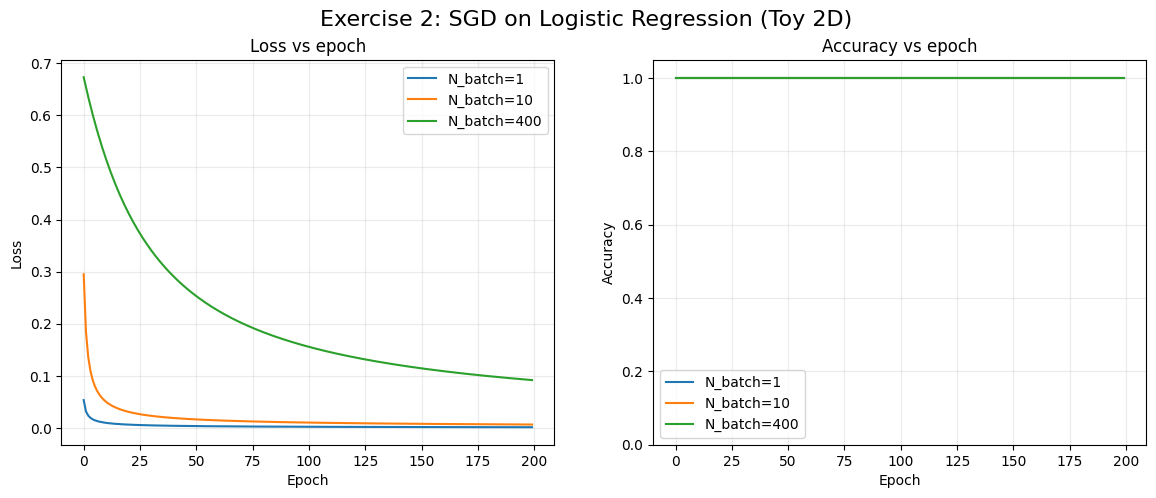

In [14]:
X_raw, y = make_toy_data(n0=200, n1=200, seed=0)
X = add_bias(X_raw)
N = X.shape[0]

lr = 1e-2
epochs = 200

batch_sizes = [1, 10, N]  # N means full GD

results = {}
for bs in batch_sizes:
    theta, losses, accs = train_sgd_logreg(L, grad_L, X, y, lr=lr, epochs=epochs, batch_size=bs, seed=0)
    results[bs] = (theta, losses, accs)
    print(f"N_batch={bs:>4} | final loss={losses[-1]:.4f} | final acc={accs[-1]*100:.2f}% | theta={theta.ravel()}")
plot_loss_acc(results, title="Exercise 2: SGD on Logistic Regression (Toy 2D)")